In [1]:
from main import *
from Utils.plotting_functions import *
from Worlds.World import World
import Drone.Simulation
from matplotlib import pyplot as plt
from Optimizations.opt_func import calculate_costs

parameters = load_parameters("Settings/simulation_parameters.yaml")
init_state = create_initial_state()
thrust_max = get_max_thrust_from_rotor_model(parameters)
pid_gains = load_pid_gains(parameters)
quad_controller = create_quadcopter_controller(init_state, pid_gains, thrust_max, parameters)
drone = create_quadcopter_model(init_state, quad_controller, parameters)
world = World.load_world(parameters['world_data_path'])
noise_model = load_dnn_noise_model(parameters)

In [2]:
waypoints = [
    {"x": 0, "y": 0, "z": 0, "v": 5},
    {"x": 1000, "y": 1000, "z": 10, "v": 5},
]

In [ ]:
sim = Simulation(
    drone,
    world,
    waypoints, 
    dt=float(parameters['dt']),
    max_simulation_time=float(parameters['simulation_time']),
    frame_skip=int(parameters['frame_skip']),
    target_reached_threshold=float(parameters['threshold']),
    target_shift_threshold_distance=float(parameters['target_shift_threshold_distance']),
    noise_model=noise_model,
    generate_sound_emission_map=True,
    compute_psychoacoustics=False,
    noise_annoyance_radius=9,
)
sim.startSimulation(stop_at_target=True, use_static_target=True, verbose=True)
costs = calculate_costs(sim, parameters['simulation_time'], weight_penalties=True, noise_weight=2e-25, altitude_weight=1e-2)
print(f"Total costs: {costs}")

Final target reached at time: 102.80 s
Simulation completed in 18.03 seconds.
Total costs: {'total_cost': 185.76863162397663, 'time_cost': 102.8, 'power_cost': 9.319001928710938, 'noise_cost': 62.79665769238173, 'n_waypoints_completed': 2, 'tot_waypoints': 2}


In [15]:
waypoints_list = [(x,y,z) for x,y,z in [(wp['x'], wp['y'], wp['z']) for wp in waypoints]]
del waypoints_list[-1]

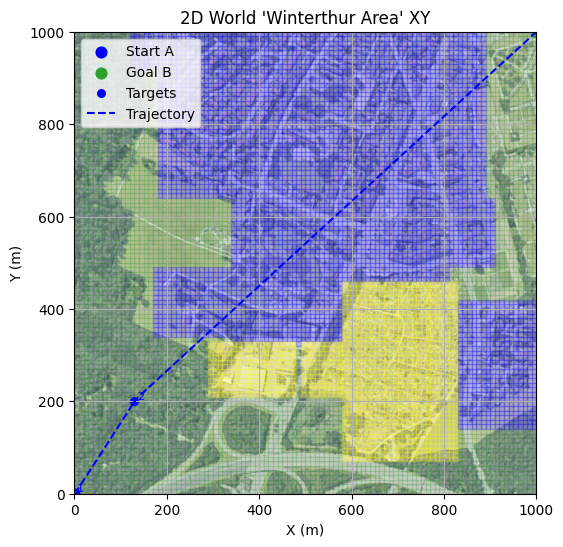

In [16]:
show2DWorld(
    world, sim.positions, waypoints[0], waypoints[-1], waypoints_list)
